## Sentiment Analysis in Python
in this notebook we will be doing some sentiment analysis in python using:

1. VADER(Valence Aware Dictionary and Sentiment Reasoner) - Bag of words approach


## Step 1. Read in Data and NLTK Basics

In [19]:
# Importing the required libraries for data manipulation, numerical operations, and visualization
import pandas as pd  # Library for data manipulation and analysis
import numpy as np  # Library for numerical operations
import matplotlib.pyplot as plt  # Library for creating static, animated, and interactive visualizations
import seaborn as sns  # Library for making statistical graphics in Python

# Setting the plot style to 'ggplot' for better aesthetics
plt.style.use('ggplot')

# Importing the Natural Language Toolkit library for natural language processing tasks
import nltk

In [20]:
# Reading the dataset from the specified path
df = pd.read_csv('../input/amazon-fine-food-reviews/Reviews.csv')

# Printing the shape of the dataset (number of rows and columns)
print(df.shape)

# Selecting the first 500 rows of the dataset
df = df.head(500)

# Printing the shape of the reduced dataset
print(df.shape)


(568454, 10)
(500, 10)


In [21]:
# Displaying the first 5 rows of the dataset
df.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [22]:
# Accessing and displaying the first text entry in the 'Text' column of the dataset
df['Text'].values[0]


'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

## Quick EDA


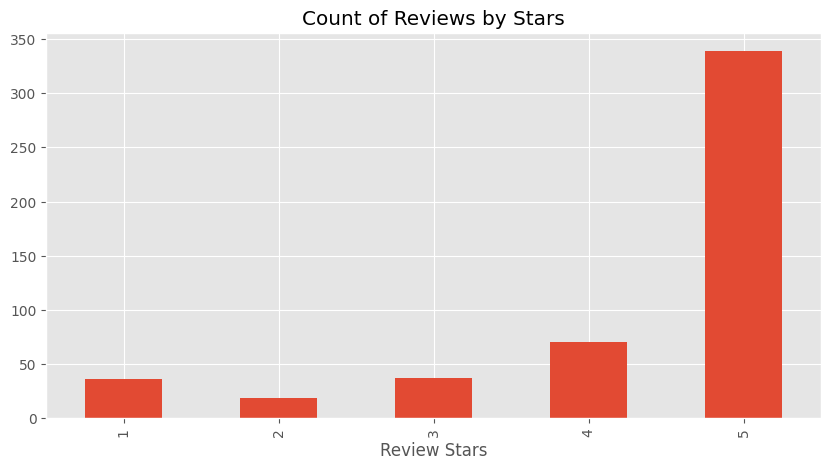

In [23]:
# Plotting the count of reviews by star ratings
ax = df['Score'].value_counts().sort_index() \
    .plot(kind='bar',              # Creating a bar plot
          title='Count of Reviews by Stars',  # Setting the title of the plot
          figsize=(10, 5))         # Setting the figure size
          
# Setting the label for the x-axis
ax.set_xlabel('Review Stars')

# Displaying the plot
plt.show()


## Basic NLTK

In [24]:
# Accessing the text entry at index 50 in the 'Text' column of the dataset
example = df['Text'][50]

# Printing the text entry to the console
print(example)


This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


In [25]:
# Tokenizing the text entry using NLTK's word_tokenize function
tokens = nltk.word_tokenize(example)

# Displaying the first 10 tokens from the tokenized text
tokens[:10]


['This', 'oatmeal', 'is', 'not', 'good', '.', 'Its', 'mushy', ',', 'soft']

In [26]:
# Tagging the tokens with their part-of-speech tags using NLTK's pos_tag function
tagged = nltk.pos_tag(tokens)

# Displaying the first 10 tagged tokens
tagged[:10]


[('This', 'DT'),
 ('oatmeal', 'NN'),
 ('is', 'VBZ'),
 ('not', 'RB'),
 ('good', 'JJ'),
 ('.', '.'),
 ('Its', 'PRP$'),
 ('mushy', 'NN'),
 (',', ','),
 ('soft', 'JJ')]

In [27]:
# Performing Named Entity Recognition (NER) on the tagged tokens using NLTK's ne_chunk function
entities = nltk.chunk.ne_chunk(tagged)

# Printing the extracted named entities in a readable format
entities.pprint()


(S
  This/DT
  oatmeal/NN
  is/VBZ
  not/RB
  good/JJ
  ./.
  Its/PRP$
  mushy/NN
  ,/,
  soft/JJ
  ,/,
  I/PRP
  do/VBP
  n't/RB
  like/VB
  it/PRP
  ./.
  (ORGANIZATION Quaker/NNP Oats/NNPS)
  is/VBZ
  the/DT
  way/NN
  to/TO
  go/VB
  ./.)


## Step 2. VADER Sentiment Scoring
We will use NLTK,s SentimentIntensityAnalyzer to get the neg/neu/pos scores of the text.

* This uses a "bag of words" approach:
    1. Stop words are removed
    2. each word is scored and combined to a total score 

In [28]:
# Importing the Sentiment Intensity Analyzer from NLTK for sentiment analysis
from nltk.sentiment import SentimentIntensityAnalyzer
import warnings

warnings.filterwarnings("ignore", message="The twython library has not been installed. Some functionality from the twitter package will not be available.")


# Importing tqdm for creating progress bars
from tqdm.notebook import tqdm

# Creating an instance of the Sentiment Intensity Analyzer
sia = SentimentIntensityAnalyzer()


In [29]:
# Calculating the sentiment polarity scores for the given text using Sentiment Intensity Analyzer
sia.polarity_scores('I am so happy!')


{'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.6468}

In [30]:
# Calculating the sentiment polarity scores for the given text using Sentiment Intensity Analyzer
sia.polarity_scores('This is worst thing ever.')


{'neg': 0.506, 'neu': 0.494, 'pos': 0.0, 'compound': -0.6249}

In [31]:
# Calculating the sentiment polarity scores for the 'example' text using Sentiment Intensity Analyzer
sia.polarity_scores(example)


{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [32]:
# Initializing an empty dictionary to store the sentiment scores
res = {}

# Iterating over each row in the dataset using tqdm for displaying a progress bar
for i, row in tqdm(df.iterrows(), total=len(df)):
    # Extracting the text and ID from each row
    text = row['Text']
    myid = row['Id']
    
    # Calculating the sentiment polarity scores for the text
    res[myid] = sia.polarity_scores(text)


  0%|          | 0/500 [00:00<?, ?it/s]

In [33]:
# Converting the dictionary of sentiment scores into a DataFrame and transposing it
vaders = pd.DataFrame(res).T

# Resetting the index and renaming the 'index' column to 'Id'
vaders = vaders.reset_index().rename(columns={'index': 'Id'})

# Merging the sentiment scores DataFrame with the original DataFrame based on the 'Id' column
vaders = vaders.merge(df, how='left')


In [34]:
# Displaying the first 5 rows of the DataFrame containing sentiment scores and metadata
vaders.head()


,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.079,0.853,0.068,-0.1027,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Plt VADERS results

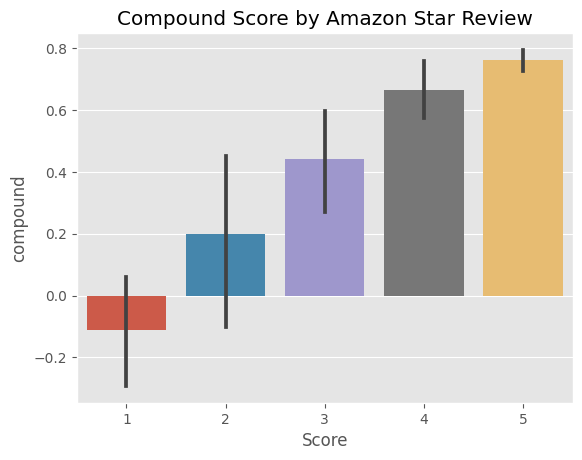

In [35]:
# Creating a bar plot to visualize the compound sentiment scores by Amazon star reviews
ax = sns.barplot(data=vaders, x='Score', y='compound')

# Setting the title of the plot
ax.set_title('Compound Score by Amazon Star Review')

# Displaying the plot
plt.show()


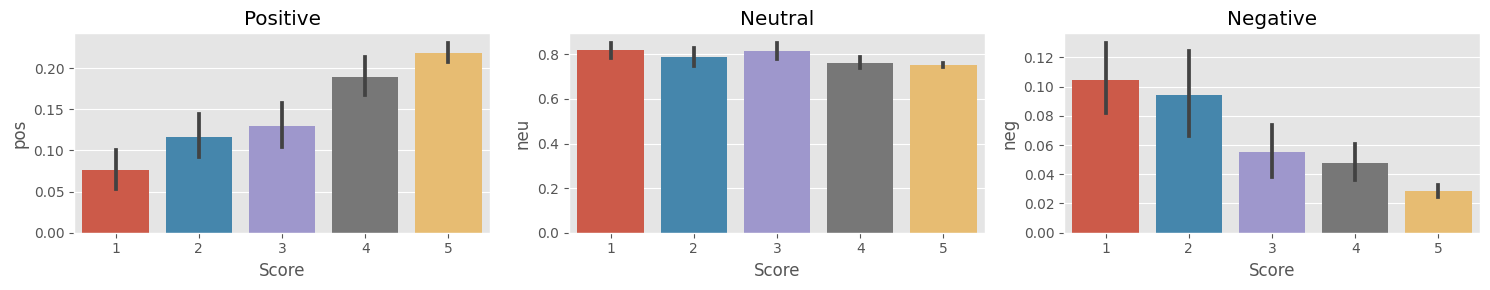

In [36]:
# Creating a figure with 3 subplots arranged in a single row
fig, axs = plt.subplots(1, 3, figsize=(15, 3))

# Creating a bar plot for positive sentiment scores by Amazon star reviews
sns.barplot(data=vaders, x='Score', y='pos', ax=axs[0])

# Creating a bar plot for neutral sentiment scores by Amazon star reviews
sns.barplot(data=vaders, x='Score', y='neu', ax=axs[1])

# Creating a bar plot for negative sentiment scores by Amazon star reviews
sns.barplot(data=vaders, x='Score', y='neg', ax=axs[2])

# Setting the titles for each subplot
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')

# Adjusting the layout to avoid overlap
plt.tight_layout()

# Displaying the plots
plt.show()
